<a href="https://colab.research.google.com/github/daniyalali72/battery-health-prediction/blob/main/notebooks/01_data_extraction_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import scipy.io
import pandas as pd
import numpy as np

# Download the MATLAB file if not already present
!wget -nc https://raw.githubusercontent.com/skypelogic/NASA-Battery-Dataset/main/B0018/B0018.mat

# Load MATLAB file
mat = scipy.io.loadmat('B0018.mat')
battery_key = [k for k in mat.keys() if not k.startswith('__')][0]
cycles = mat[battery_key][0, 0]['cycle'][0]

cycle_list = []
capacity_list = []
cycle_counter = 1

for c in cycles:
    c_type = c['type'][0]
    if c_type == 'discharge':
        data = c['data'][0, 0]
        # Check if Capacity is recorded in this discharge cycle
        if 'Capacity' in data.dtype.names and len(data['Capacity']) > 0:
            cap = float(data['Capacity'][0, 0])
            cycle_list.append(cycle_counter)
            capacity_list.append(cap)
            cycle_counter += 1

# Create clean DataFrame
df = pd.DataFrame({
    'Cycle': cycle_list,
    'Capacity_Ah': capacity_list
})

# Calculate State of Health (SoH) against nominal 2.0 Ah rating
NOMINAL_CAPACITY = 2.0
df['SoH'] = df['Capacity_Ah'] / NOMINAL_CAPACITY

print(f"Dataset key: {battery_key}")
print(f"Total discharge cycles extracted: {len(df)}")
print(f"Cycle 1 - Capacity: {df['Capacity_Ah'].iloc[0]:.4f} Ah | SoH: {df['SoH'].iloc[0]*100:.2f}%")
print(f"Final Cycle ({df['Cycle'].iloc[-1]}) - Capacity: {df['Capacity_Ah'].iloc[-1]:.4f} Ah | SoH: {df['SoH'].iloc[-1]*100:.2f}%")

df.head()

--2026-09-27 08:27:03--  https://raw.githubusercontent.com/skypelogic/NASA-Battery-Dataset/main/B0018/B0018.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-27 08:27:03 ERROR 404: Not Found.



FileNotFoundError: [Errno 2] No such file or directory: 'B0018.mat'

In [3]:
import scipy.io
import pandas as pd
import numpy as np

# Notice the leading slash '/B0018.mat' pointing to your file's exact location
mat = scipy.io.loadmat('/B0018.mat')

battery_key = [k for k in mat.keys() if not k.startswith('__')][0]
cycles = mat[battery_key][0, 0]['cycle'][0]

cycle_list = []
capacity_list = []
cycle_counter = 1

for c in cycles:
    c_type = c['type'][0]
    if c_type == 'discharge':
        data = c['data'][0, 0]
        if 'Capacity' in data.dtype.names and len(data['Capacity']) > 0:
            cap = float(data['Capacity'][0, 0])
            cycle_list.append(cycle_counter)
            capacity_list.append(cap)
            cycle_counter += 1

# Create clean DataFrame
df = pd.DataFrame({
    'Cycle': cycle_list,
    'Capacity_Ah': capacity_list
})

# Calculate State of Health (SoH) against nominal 2.0 Ah rating
NOMINAL_CAPACITY = 2.0
df['SoH'] = df['Capacity_Ah'] / NOMINAL_CAPACITY

print(f"Dataset key: {battery_key}")
print(f"Total discharge cycles extracted: {len(df)}")
print(f"Cycle 1 - Capacity: {df['Capacity_Ah'].iloc[0]:.4f} Ah | SoH: {df['SoH'].iloc[0]*100:.2f}%")
print(f"Final Cycle ({df['Cycle'].iloc[-1]}) - Capacity: {df['Capacity_Ah'].iloc[-1]:.4f} Ah | SoH: {df['SoH'].iloc[-1]*100:.2f}%")

df.head()


Dataset key: B0018
Total discharge cycles extracted: 132
Cycle 1 - Capacity: 1.8550 Ah | SoH: 92.75%
Final Cycle (132) - Capacity: 1.3411 Ah | SoH: 67.05%


,Cycle,Capacity_Ah,SoH
0,1,1.855005,0.927502
1,2,1.843196,0.921598
2,3,1.839602,0.919801
3,4,1.830674,0.915337
4,5,1.832700,0.916350


In [4]:
import numpy as np

features_list = []

# Loop through the cycles again
for c in cycles:
    c_type = c['type'][0]

    if c_type == 'discharge':
        data = c['data'][0, 0]

        # Ensure it's a valid cycle with capacity
        if 'Capacity' in data.dtype.names and len(data['Capacity']) > 0:

            # Extract the raw, continuous sensor arrays
            temp_array = data['Temperature_measured'][0]
            voltage_array = data['Voltage_measured'][0]
            time_array = data['Time'][0]

            # Squash the arrays into single summary numbers (our features)
            features_list.append({
                'Max_Temperature_C': np.max(temp_array),
                'Avg_Temperature_C': np.mean(temp_array),
                'Min_Voltage_V': np.min(voltage_array),
                'Discharge_Time_s': time_array[-1] # The last timestamp is the total duration
            })

# Convert the features into a table and merge it with our SoH table
df_features = pd.DataFrame(features_list)
df_final = pd.concat([df, df_features], axis=1)

print("Feature Extraction Complete!")
print(df_final.head())

Feature Extraction Complete!
   Cycle  Capacity_Ah       SoH  Max_Temperature_C  Avg_Temperature_C  \
0      1     1.855005  0.927502          38.101803          31.773285   
1      2     1.843196  0.921598          38.149880          31.924892   
2      3     1.839602  0.919801          37.526691          31.316913   
3      4     1.830674  0.915337          37.062792          30.821191   
4      5     1.832700  0.916350          38.211035          31.953470   

   Min_Voltage_V  Discharge_Time_s  
0       2.472161          3434.891  
1       2.411438          3425.485  
2       2.394396          3410.375  
3       2.399948          3404.719  
4       2.385146          3417.641  


In [5]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Separate the clues (X) from the answer (y)
features = ['Max_Temperature_C', 'Avg_Temperature_C', 'Min_Voltage_V', 'Discharge_Time_s']
X = df_final[features]
y = df_final['SoH']

# 2. The Sequential Split (NO RANDOM SHUFFLING)
# Train on the first 100 cycles, test on the remaining 32 cycles
split_index = 100
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 3. Train the XGBoost Baseline Model
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# 4. Give the model the final exam (predicting the hidden 32 cycles)
predictions = model.predict(X_test)

# 5. Calculate the error margin
mse = mean_squared_error(y_test, predictions) # Remove squared=False
rmse = np.sqrt(mse) # Manually calculate RMSE
print(f"Model Error (RMSE): {rmse:.4f} (Lower is better)
")

# 6. Graph the AI's prediction against the physical reality
plt.figure(figsize=(10, 5))
plt.plot(df_final['Cycle'], y, label='Actual SoH', color='blue', linewidth=2)
plt.plot(df_final['Cycle'].iloc[split_index:], predictions, label='XGBoost Prediction', color='red', linestyle='--', linewidth=2)
plt.axvline(x=split_index, color='gray', linestyle=':', label='Train/Test Boundary')
plt.title('Battery B0018: XGBoost SoH Prediction')
plt.xlabel('Cycle Number')
plt.ylabel('State of Health (SoH)')
plt.legend()
plt.grid(True)
plt.show()

TypeError: got an unexpected keyword argument 'squared'

Model Error (RMSE): 0.0100 (Lower is better)


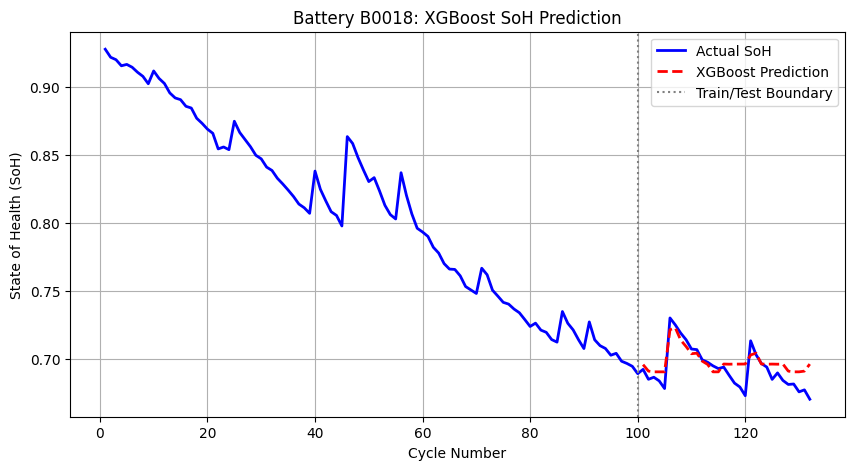

In [6]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Separate the clues (X) from the answer (y)
features = ['Max_Temperature_C', 'Avg_Temperature_C', 'Min_Voltage_V', 'Discharge_Time_s']
X = df_final[features]
y = df_final['SoH']

# 2. The Sequential Split (NO RANDOM SHUFFLING)
# Train on the first 100 cycles, test on the remaining 32 cycles
split_index = 100
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 3. Train the XGBoost Baseline Model
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# 4. Give the model the final exam (predicting the hidden 32 cycles)
predictions = model.predict(X_test)

# 5. Calculate the error margin (UPDATED FIX)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(f"Model Error (RMSE): {rmse:.4f} (Lower is better)")

# 6. Graph the AI's prediction against the physical reality
plt.figure(figsize=(10, 5))
plt.plot(df_final['Cycle'], y, label='Actual SoH', color='blue', linewidth=2)
plt.plot(df_final['Cycle'].iloc[split_index:], predictions, label='XGBoost Prediction', color='red', linestyle='--', linewidth=2)
plt.axvline(x=split_index, color='gray', linestyle=':', label='Train/Test Boundary')
plt.title('Battery B0018: XGBoost SoH Prediction')
plt.xlabel('Cycle Number')
plt.ylabel('State of Health (SoH)')
plt.legend()
plt.grid(True)
plt.show()

Parsing raw NASA datasets...
Training XGBoost on B0005 and B0018...
Final Baseline RMSE on Unseen Battery B0006: 0.0410


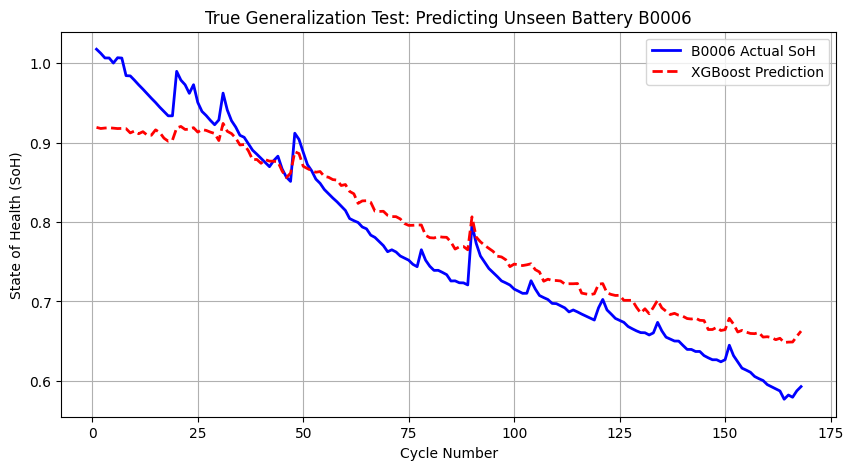

In [7]:
import scipy.io
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Master Extraction Function
def extract_features(filename, battery_name):
    mat = scipy.io.loadmat(filename)
    battery_key = [k for k in mat.keys() if not k.startswith('__')][0]
    cycles = mat[battery_key][0, 0]['cycle'][0]

    extracted_data = []
    cycle_counter = 1

    for c in cycles:
        if c['type'][0] == 'discharge':
            data = c['data'][0, 0]
            if 'Capacity' in data.dtype.names and len(data['Capacity']) > 0:
                cap = float(data['Capacity'][0, 0])
                temp_array = data['Temperature_measured'][0]
                voltage_array = data['Voltage_measured'][0]
                time_array = data['Time'][0]

                extracted_data.append({
                    'Battery': battery_name,
                    'Cycle': cycle_counter,
                    'Capacity_Ah': cap,
                    'SoH': cap / 2.0, # Nominal 2.0 Ah
                    'Max_Temperature_C': np.max(temp_array),
                    'Avg_Temperature_C': np.mean(temp_array),
                    'Min_Voltage_V': np.min(voltage_array),
                    'Discharge_Time_s': time_array[-1]
                })
                cycle_counter += 1

    return pd.DataFrame(extracted_data)

# 2. Process All Batteries (Note the leading slashes for the root folder)
print("Parsing raw NASA datasets...")
df_b05 = extract_features('/B0005.mat', 'B0005')
df_b18 = extract_features('/B0018.mat', 'B0018')
df_b06 = extract_features('/B0006.mat', 'B0006')

# 3. The True Generalization Split
# Train on B0005 and B0018 combined. Test ONLY on B0006.
df_train = pd.concat([df_b05, df_b18], ignore_index=True)
df_test = df_b06

features = ['Max_Temperature_C', 'Avg_Temperature_C', 'Min_Voltage_V', 'Discharge_Time_s']
X_train, y_train = df_train[features], df_train['SoH']
X_test, y_test = df_test[features], df_test['SoH']

# 4. Train the Baseline
print("Training XGBoost on B0005 and B0018...")
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# 5. Administer the Blind Test
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Final Baseline RMSE on Unseen Battery B0006: {rmse:.4f}")

# 6. Plot the Final Results
plt.figure(figsize=(10, 5))
plt.plot(df_test['Cycle'], y_test, label='B0006 Actual SoH', color='blue', linewidth=2)
plt.plot(df_test['Cycle'], predictions, label='XGBoost Prediction', color='red', linestyle='--', linewidth=2)
plt.title('True Generalization Test: Predicting Unseen Battery B0006')
plt.xlabel('Cycle Number')
plt.ylabel('State of Health (SoH)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Scale the data (Compressing everything between 0 and 1)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit the scaler ONLY on the training fleet (B0005, B0018) to prevent data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# Transform the test battery (B0006) using the rules learned from the training fleet
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# 2. Reshape into 3D Sequences (The Sliding Window)
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        # Grab a block of 10 consecutive cycles
        Xs.append(X[i:(i + time_steps)])
        # The target answer is the 11th cycle
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# We will look at the past 10 cycles to predict the health of the next one
TIME_STEPS = 10

X_train_3d, y_train_3d = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_3d, y_test_3d = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print("Data successfully scaled and reshaped!")
print(f"Old 2D Training Matrix: {X_train_scaled.shape}")
print(f"New 3D Training Matrix: {X_train_3d.shape} -> (Samples, Time Steps, Features)")

Data successfully scaled and reshaped!
Old 2D Training Matrix: (300, 4)
New 3D Training Matrix: (290, 10, 4) -> (Samples, Time Steps, Features)


Training LSTM Neural Network on Cloud GPU...
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1809 - val_loss: 0.0041
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0750 - val_loss: 0.0050
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0292 - val_loss: 0.0031
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0256 - val_loss: 0.0045
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0259 - val_loss: 0.0049
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0257 - val_loss: 0.0040
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0209 - val_loss: 0.0029
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0226 - val_loss: 0.0031
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0203 - val_loss: 0.0030
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0193 - val_loss: 0.0029
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0177 - val_loss: 0.0028
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0207 - val_loss: 0.0031

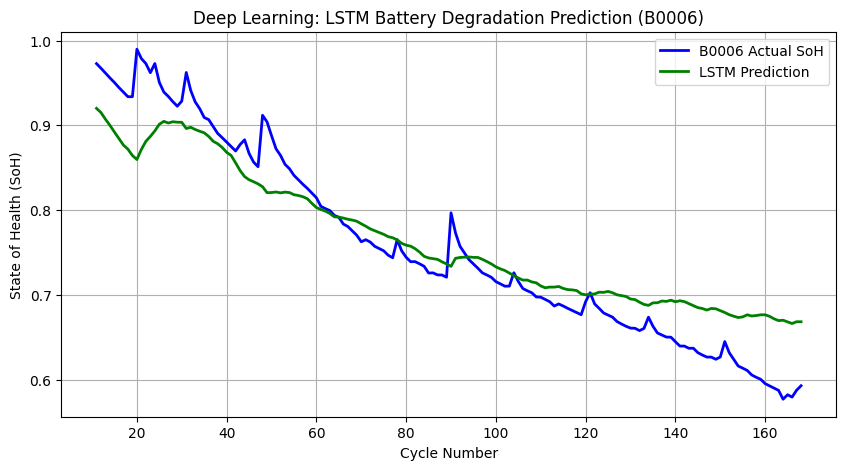

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Build the LSTM Architecture
lstm_model = Sequential()
# The LSTM layer reads the 3D matrix (10 time steps, 4 features)
lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])))
lstm_model.add(Dropout(0.2)) # Randomly drops 20% of neurons to prevent memorization (overfitting)
lstm_model.add(Dense(1)) # The final output node that spits out the SoH prediction

lstm_model.compile(optimizer='adam', loss='mse')

# 2. Train the Neural Network
print("Training LSTM Neural Network on Cloud GPU...")
# We run 50 epochs (training passes) over the data
history = lstm_model.fit(X_train_3d, y_train_3d, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# 3. Take the Final Exam on Battery B0006
lstm_predictions_scaled = lstm_model.predict(X_test_3d)

# 4. Un-scale the data back to readable SoH percentages
lstm_predictions = scaler_y.inverse_transform(lstm_predictions_scaled)
actual_y_test = scaler_y.inverse_transform(y_test_3d)

# 5. Calculate Final Error
lstm_rmse = np.sqrt(mean_squared_error(actual_y_test, lstm_predictions))
print(f"\n--- FINAL RESULTS ---")
print(f"LSTM RMSE on Unseen Battery B0006: {lstm_rmse:.4f}")

# 6. Plot the Deep Learning Masterpiece
plt.figure(figsize=(10, 5))
# We start plotting at cycle 10 because the first 10 cycles were used to predict cycle 11
plt.plot(df_test['Cycle'].iloc[TIME_STEPS:], actual_y_test, label='B0006 Actual SoH', color='blue', linewidth=2)
plt.plot(df_test['Cycle'].iloc[TIME_STEPS:], lstm_predictions, label='LSTM Prediction', color='green', linewidth=2)
plt.title('Deep Learning: LSTM Battery Degradation Prediction (B0006)')
plt.xlabel('Cycle Number')
plt.ylabel('State of Health (SoH)')
plt.legend()
plt.grid(True)
plt.show()